<a href="https://colab.research.google.com/github/SSubhash1/DL-LAB/blob/main/DL_LAB_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.4671 - mae: 0.8243 - val_loss: 0.4601 - val_mae: 0.5189
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3748 - mae: 0.4348 - val_loss: 0.3962 - val_mae: 0.4305
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3519 - mae: 0.4186 - val_loss: 0.3681 - val_mae: 0.4174
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3311 - mae: 0.4029 - val_loss: 0.3529 - val_mae: 0.4128
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3229 - mae: 0.3983 - val_loss: 0.3632 - val_mae: 0.4065
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3059 - mae: 0.3842 - val_loss: 0.3347 - val_mae: 0.4021
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2960 - mae: 0.3792 - val_loss: 0.3313 - val_mae: 0.4049
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2890 - mae: 0.3710 - val_loss: 0.3233 - val_mae: 0.3954
Epoch 9/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

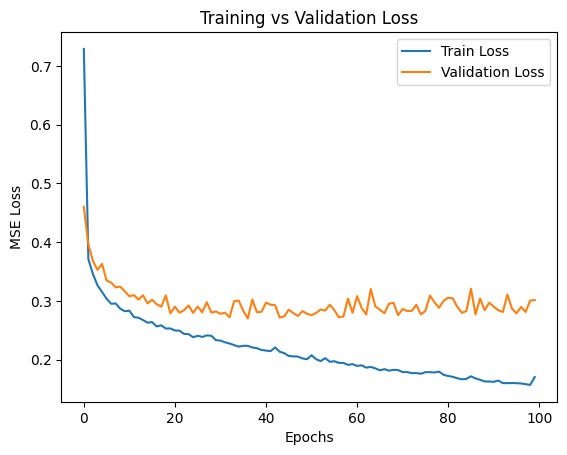

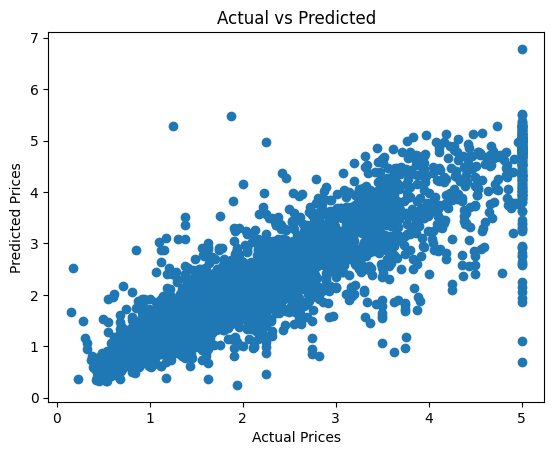

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Linear activation for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    verbose=1
)

# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.4911 - mae: 0.8346 - val_loss: 0.4152 - val_mae: 0.4601
Epoch 2/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3900 - mae: 0.4434 - val_loss: 0.3750 - val_mae: 0.4337
Epoch 3/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3488 - mae: 0.4166 - val_loss: 0.3524 - val_mae: 0.4257
Epoch 4/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3486 - mae: 0.4173 - val_loss: 0.3348 - val_mae: 0.4124
Epoch 5/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3365 - mae: 0.4054 - val_loss: 0.3330 - val_mae: 0.3995
Epoch 6/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3210 - mae: 0.3906 - val_loss: 0.3106 - val_mae: 0.3965
Epoch 7/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2941 - mae: 0.3764 - val_loss: 0.3082 - val_mae: 0.3875
Epoch 8/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2929 - mae: 0.3760 - val_loss: 0.3045 - val_mae: 0.3830
Epoch 9/100
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

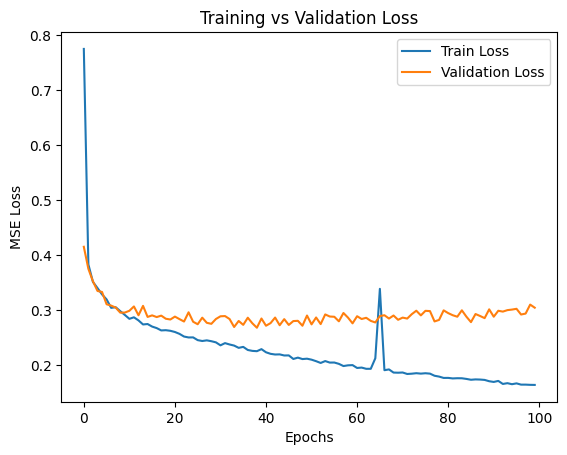

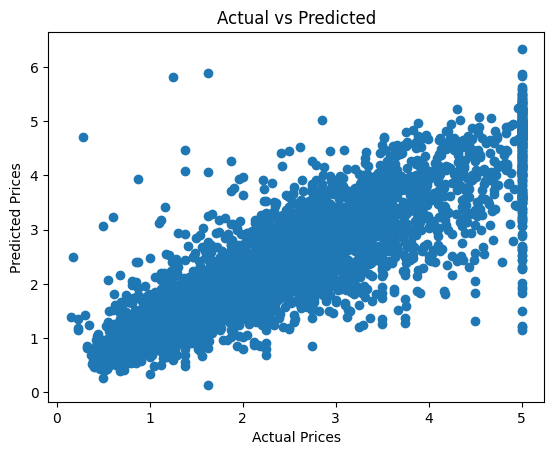

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Linear activation for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    verbose=1
)

# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.0615 - mae: 0.7116 - val_loss: 0.4197 - val_mae: 0.4569
Epoch 2/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3665 - mae: 0.4321 - val_loss: 0.3799 - val_mae: 0.4324
Epoch 3/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3347 - mae: 0.4079 - val_loss: 0.3708 - val_mae: 0.4144
Epoch 4/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3272 - mae: 0.3986 - val_loss: 0.3427 - val_mae: 0.3999
Epoch 5/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3064 - mae: 0.3833 - val_loss: 0.3250 - val_mae: 0.3897
Epoch 6/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2946 - mae: 0.3745 - val_loss: 0.3372 - val_mae: 0.4102
Epoch 7/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2958 - mae: 0.3773 - val_loss: 0.3282 - val_mae: 0.3867
Epoch 8/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2838 - mae: 0.3675 - val_loss: 0.3117 - val_mae: 0.3791
Epoch 9/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

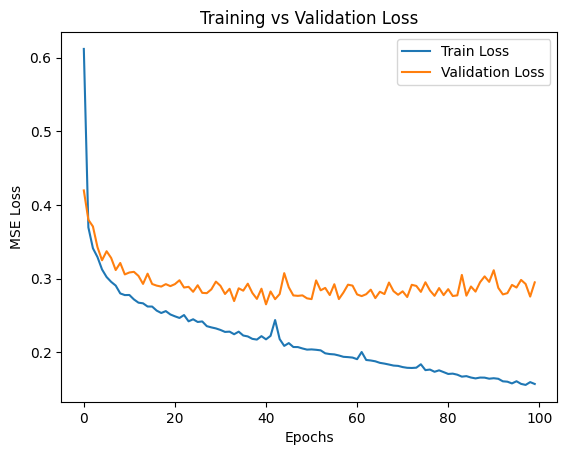

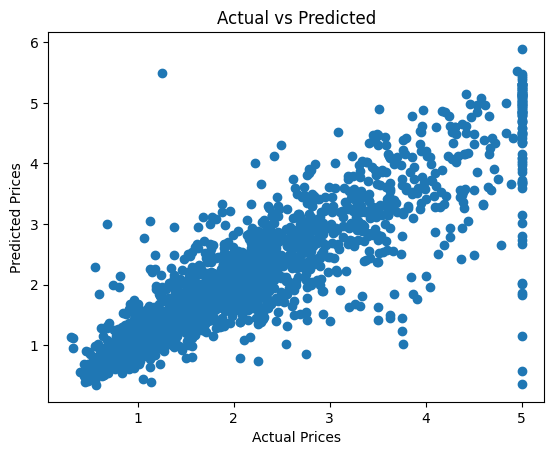

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Linear activation for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    verbose=1
)

# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.6662 - mae: 0.9012 - val_loss: 0.4435 - val_mae: 0.4902
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4148 - mae: 0.4571 - val_loss: 0.4013 - val_mae: 0.4673
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3517 - mae: 0.4221 - val_loss: 0.3813 - val_mae: 0.4433
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3438 - mae: 0.4118 - val_loss: 0.3537 - val_mae: 0.4143
Epoch 5/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3267 - mae: 0.3988 - val_loss: 0.3564 - val_mae: 0.4128
Epoch 6/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3223 - mae: 0.3934 - val_loss: 0.3416 - val_mae: 0.4096
Epoch 7/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3087 - mae: 0.3887 - val_loss: 0.3319 - val_mae: 0.4054
Epoch 8/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3075 - mae: 0.3871 - val_loss: 0.3421 - val_mae: 0.3917
Epoch 9/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

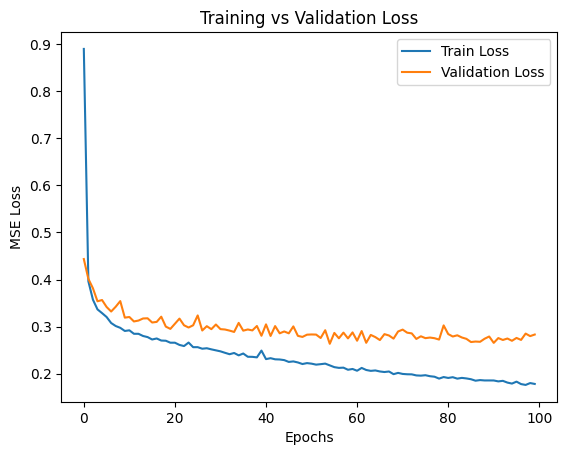

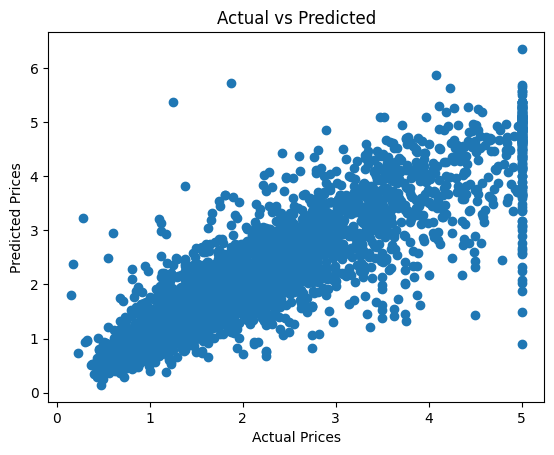

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Linear activation for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    verbose=1
)

# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 2.6810 - mae: 1.1984 - val_loss: 0.6196 - val_mae: 0.5479
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5347 - mae: 0.5144 - val_loss: 0.4379 - val_mae: 0.4675
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4032 - mae: 0.4537 - val_loss: 0.4106 - val_mae: 0.4565
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3723 - mae: 0.4339 - val_loss: 0.4004 - val_mae: 0.4362
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3552 - mae: 0.4213 - val_loss: 0.3806 - val_mae: 0.4362
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3357 - mae: 0.4093 - val_loss: 0.3671 - val_mae: 0.4294
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3172 - mae: 0.3996 - val_loss: 0.3583 - val_mae: 0.4220
Epoch 8/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3173 - mae: 0.3999 - val_loss: 0.3721 - val_mae: 0.4451
Epoch 9/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

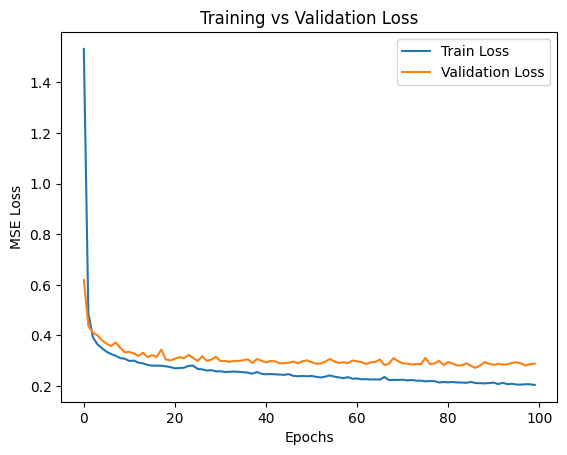

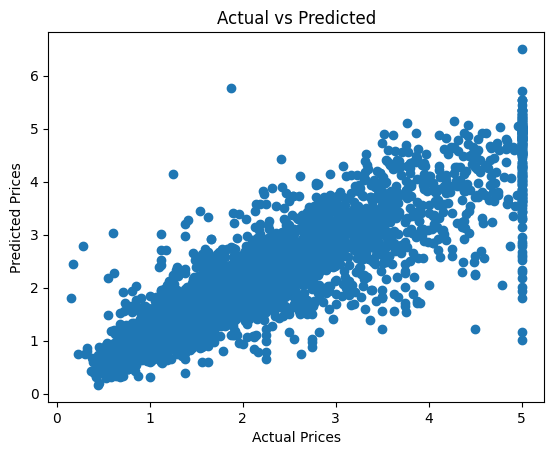

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Linear activation for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=128,
    verbose=1
)

# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 4.3303 - mae: 1.7169 - val_loss: 1.1981 - val_mae: 0.8443
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.2155 - mae: 0.7851 - val_loss: 0.7343 - val_mae: 0.6117
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.7430 - mae: 0.6047 - val_loss: 0.5782 - val_mae: 0.5443
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5659 - mae: 0.5286 - val_loss: 0.4839 - val_mae: 0.4962
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4577 - mae: 0.4793 - val_loss: 0.4455 - val_mae: 0.4792
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4123 - mae: 0.4551 - val_loss: 0.4270 - val_mae: 0.4581
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3907 - mae: 0.4428 - val_loss: 0.4132 - val_mae: 0.4484
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3600 - mae: 0.4243 - val_loss: 0.4077 - val_mae: 0.4525
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0

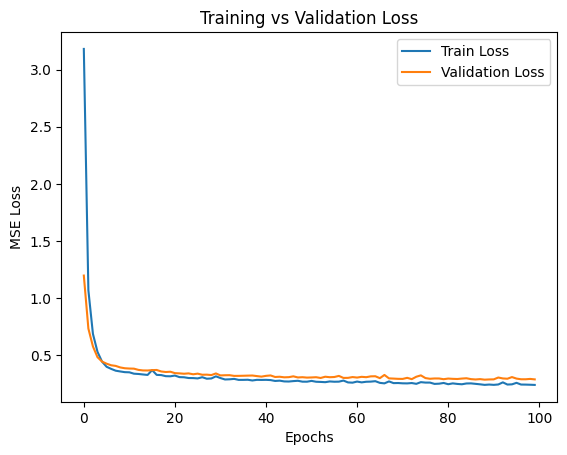

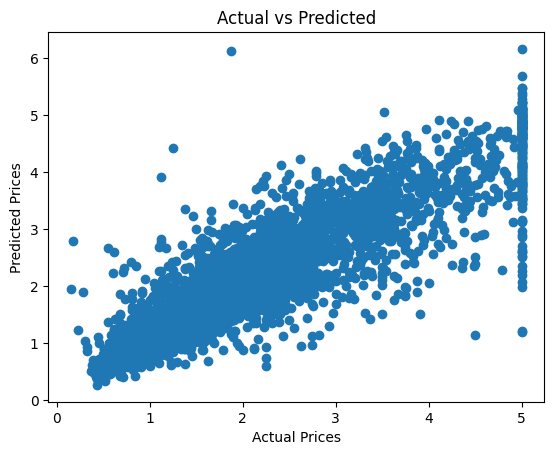

In [ ]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Linear activation for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=512,
    verbose=1
)

# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()